# Reducer Benchmark Graphs

In [10]:
# Setup
import json
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("benchmark_graphs")
OUTPUT_DIR.mkdir(exist_ok=True)

DATA_PATH_CANDIDATES = [
    Path("benchmark_data.json"),
    Path("python/benchmarks/benchmark_data.json"),
]
DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Benchmark data not found.")

with DATA_PATH.open() as data_file:
    benchmark_data = json.load(data_file)

original_tokens = benchmark_data["original_tokens"]
final_tokens = benchmark_data["final_tokens"]
wall_clock_seconds = benchmark_data["wall_clock_seconds"]

query_ids = list(range(1, len(original_tokens) + 1))
labels = [f"Q{query_id}" for query_id in query_ids]

def percentage_reductions(original: list[int], final: list[int]) -> list[float]:
    reductions: list[float] = []
    for original_count, final_count in zip(original, final, strict=True):
        if original_count <= 0:
            reductions.append(0.0)
        else:
            reductions.append(max(0.0, (original_count - final_count) / original_count * 100.0))
    return reductions

def reductions_per_second(reductions: list[float], seconds: list[float]) -> list[float]:
    rates: list[float] = []
    for reduction, duration in zip(reductions, seconds, strict=True):
        if duration <= 0:
            rates.append(0.0)
        else:
            rates.append(reduction / duration)
    return rates

def draw_bar_chart(title: str, y_label: str, values: list[float], color: str, output_name: str):
    fig, ax = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
    bars = ax.bar(labels, values, color=color)
    ax.set_title(title)
    ax.set_xlabel("Benchmark query")
    ax.set_ylabel(y_label)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
    ax.tick_params(axis="x", rotation=45)
    # Uncomment the line to save the graphs.
    # fig.savefig(OUTPUT_DIR / output_name, dpi=200)
    return fig, ax

token_reduction_percent = percentage_reductions(original_tokens, final_tokens)
token_reduction_percent_per_second = reductions_per_second(
    token_reduction_percent,
    wall_clock_seconds,
)

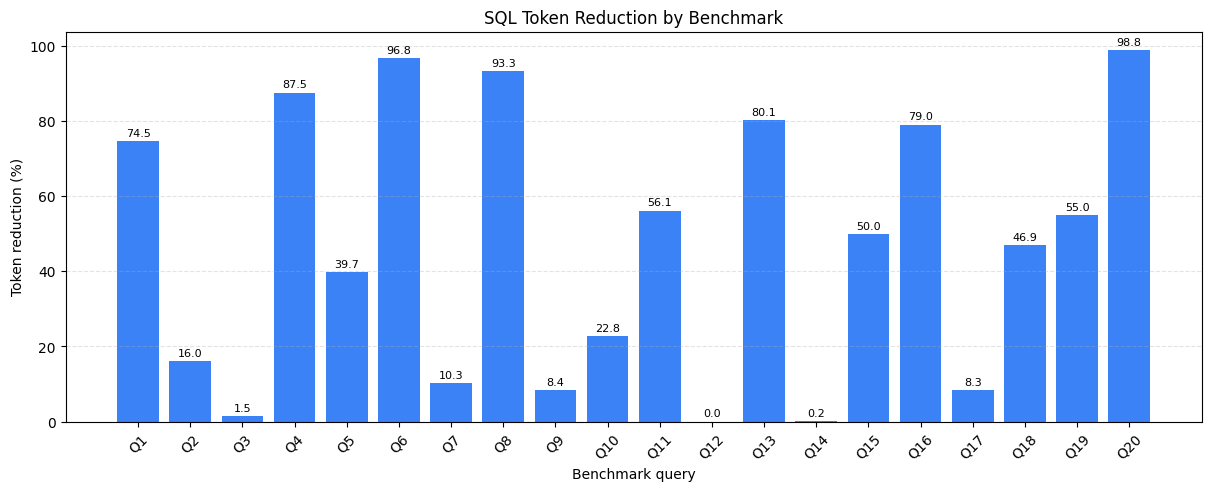

In [11]:
# Graph 1: percentage reduction in SQL tokens between original and final query
fig, ax = draw_bar_chart(
    title="SQL Token Reduction by Benchmark",
    y_label="Token reduction (%)",
    values=token_reduction_percent,
    color="#3b82f6",
    output_name="token_reduction_percent.png",
)

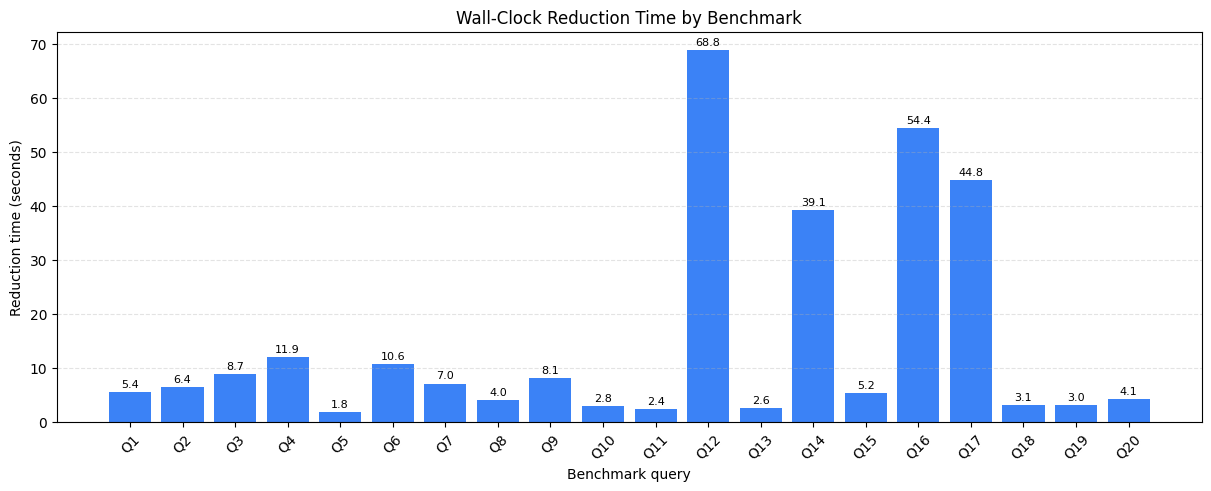

In [12]:
# Graph 2: wall-clock time required to reduce each benchmark
fig, ax = draw_bar_chart(
    title="Wall-Clock Reduction Time by Benchmark",
    y_label="Reduction time (seconds)",
    values=wall_clock_seconds,
    color="#3b82f6",
    output_name="wall_clock_seconds.png",
)

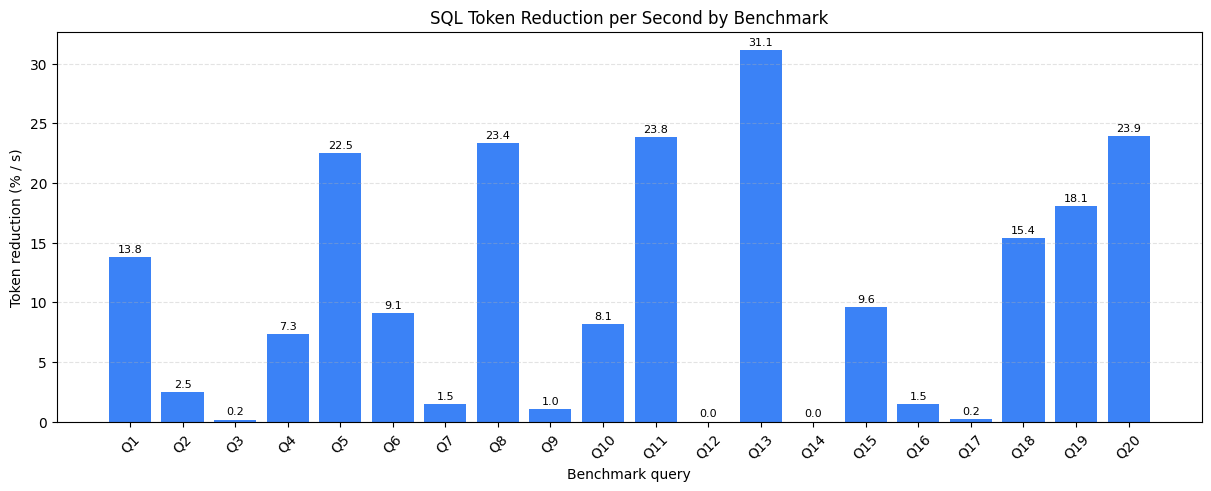

In [13]:
# Graph 3: percentage reduction in SQL tokens per second
fig, ax = draw_bar_chart(
    title="SQL Token Reduction per Second by Benchmark",
    y_label="Token reduction (% / s)",
    values=token_reduction_percent_per_second,
    color="#3b82f6",
    output_name="token_reduction_percent_per_second.png",
)